In [ ]:
# Drive mount
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
!pip install japanize-matplotlib
import japanize_matplotlib



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 43.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120306 sha256=79b4cb63d5e4cadfab58f62e9d101558c743812f284b17af2c83b7f409b571bc
  Stored in directory: /root/.cache/pip/wheels/56/8b/41/7c8a47025c6eef46f0b7488f2510fff13e48f1e7d5bf26e21b
Successfully built japanize-matplotlib


In [ ]:
# PDF操作用のライブラリをインストール
!pip install pypdf

from pypdf import PdfReader, PdfWriter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.8/393.8 kB 5.4 MB/s eta 0:00:00


報告書pdfから、必要なページを抜き出して新しいpdfを作る

In [ ]:
# ------------------------------------------------------
# 報告書pdfから、必要なページを抜き出して新しいpdfを作る「関数」
# ------------------------------------------------------

def extract_pages_from_pdf(input_pdf_path, output_pdf_path, target_pages):

    """
    PDFから特定のページを抽出して新しいPDFを作成する関数
    """
    reader = PdfReader(input_pdf_path)
    writer = PdfWriter()

    # ----- 欲しいページを追加 --------
    for page_num in target_pages:
        if 1 <= page_num <= len(reader.pages):
            page = reader.pages[page_num - 1]
            writer.add_page(page)
        else:
            print(f"警告: ページ {page_num} は存在しません。")

    # ----- 新しいPDFファイルを作成 -----
    with open(output_pdf_path, "wb") as output_file:
        writer.write(output_file)

    print(f"抽出完了: {output_pdf_path} を作成しました。")


In [ ]:
# -------------   Main -----------------

# pdf fileの読み込み
path = "/content/drive/MyDrive/38_自然言語処理/市民アンケート(2026)/2026/"
name = "R6年度市民意識調査.pdf"
input_file = path + name

# 保存する新しいPDFファイル名 ＊＊＊注意上書き＊＊＊
output_name = "調査票.pdf"
output_file = path + output_name

# 注意：実際のPDFに印字されているページ番号ではなく、PDF全体でのページ
# 例) pages_ = [15, 20] + list(range(40, 46))
# ---------------------------
# ほしいページの番号を入れる
# ---------------------------
pages = [n for n in range(226, 238, 1)]

# 関数の実行
extract_pages_from_pdf(input_file, output_file, pages)

抽出完了: /content/drive/MyDrive/38_自然言語処理/市民アンケート(2026)/2026/気胸精密検査診断書1.pdf を作成しました。


csvフアイルをpandasで読み込む

In [ ]:
import pandas as pd
import io

csv_path = "/content/drive/MyDrive/38_自然言語処理/市民アンケート(2026)/2026_csv/R6東松山市民アンケートQwen(04).csv"
# 生成されたデータをCSVファイルとして保存
with open(csv_path, "w", encoding="utf-8-sig") as f:
    f.write(csv_output)

# Pandasで読み込んで表として表示
try:
    # 文字列から直接データフレームに変換して確認
    df = pd.read_csv(io.StringIO(csv_output))
    print("Pandasでの読み込みに成功しました！")
    display(df.head())

    # 欠損値（空欄）などの簡単な確認
    print("\n【データ情報の確認】")
    print(df.info())
except Exception as e:
    print("CSVの読み込みでエラーが発生しました。Qwenの出力形式が崩れている可能性があります。")
    print("エラー詳細:", e)

生成AI用にクレンジング　　空白の除去　　改行の削除

In [ ]:
# ----------------
# DataFrame ⇒ csv
# ----------------

path = "/content/drive/MyDrive/38_自然言語処理/市民アンケート(2026)/2026_csv/"
file = "R6東松山市【高坂丘陵地区】アンケート.csv"
df_1.to_csv(path + file, encoding="utf-8-sig", index=False)

In [ ]:
# ------------------------------
# "居住地区"を選んだあと、
# アンケート内容を"分野"で分ける
# ------------------------------

category_label = df_1["分野"].unique().tolist()

# 結果の確認
print("分野＝", len(category_label))
print(category_label)

# 分野ごとに件数をカウント
summary_counts = df_1['分野'].value_counts()

# 見やすいようにデータフレームにする
summary_df = pd.DataFrame({'件数': summary_counts})
summary_df.index.name = '分野'

display(summary_df)

分野＝ 7
['都市基盤の整備について', '教育・文化・スポーツについて', '産業について', '情報について', '観光について', '市政について', 'その他']


,件数
分野,
都市基盤の整備について,2
教育・文化・スポーツについて,1
産業について,1
情報について,1
観光について,1
市政について,1
その他,1


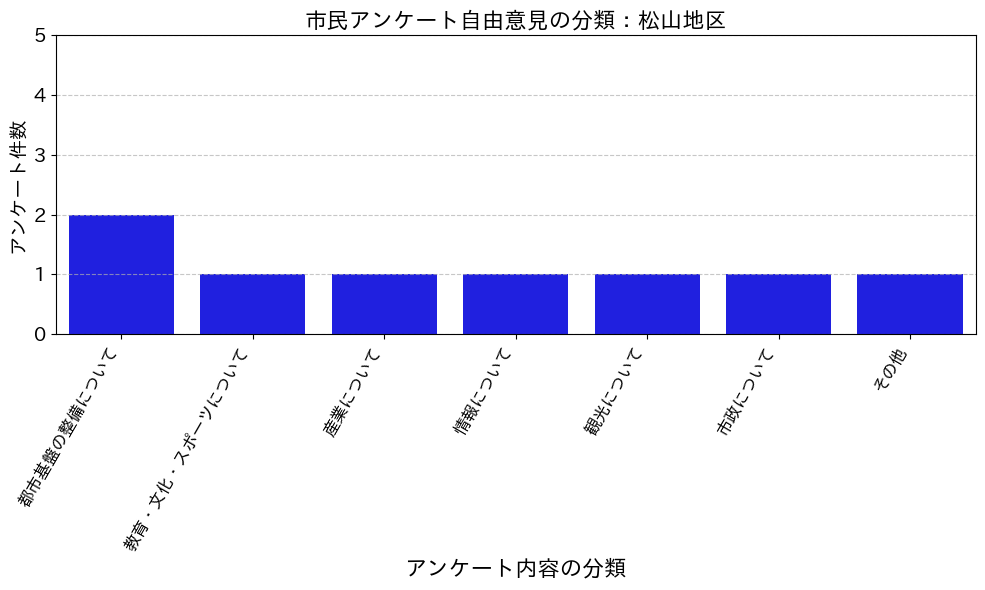

In [ ]:
# グラフ作成

plt.figure(figsize=(10, 6))

sns.barplot(x="分野", y="件数", data=summary_df, color="blue")

plt.xticks(rotation=60, ha="right", fontsize=12)

# ラベル・目盛りの設定
plt.title("市民アンケート自由意見の分類："+ str(area_labels[0]),  fontsize=16)
plt.xlabel("アンケート内容の分類", fontsize=16)
plt.ylabel("アンケート件数", fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, 5)

plt.grid(axis="y", linestyle="--", alpha=0.7)

# ラベルが見切れないようにレイアウトを自動調整
plt.tight_layout()

plt.show()

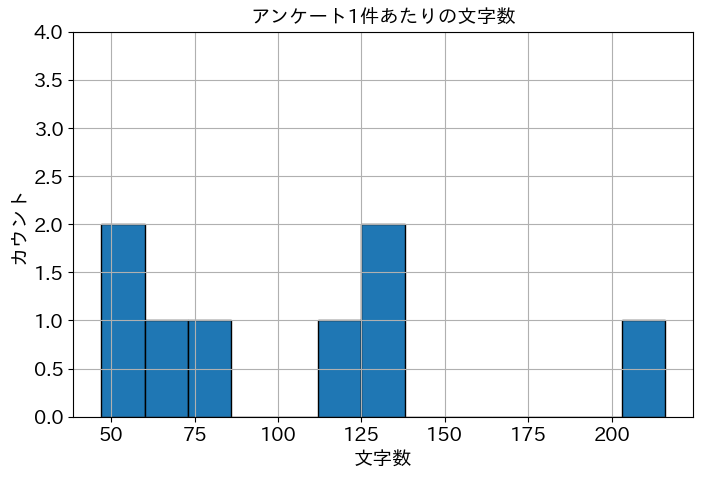

In [ ]:
"""
文字数のヒストグラム  df_1["文字数"]
"""
plt.figure(figsize=[8, 5])
plt.title("アンケート1件あたりの文字数", fontsize=14)
plt.hist(df_1["文字数"], edgecolor="black", bins=13)

plt.xticks(fontsize=14)
plt.xlabel("文字数", fontsize=14)
plt.ylabel("カウント", fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(0, 4)
plt.grid(True)
plt.show()

感情分析

--- キーワード出現回数の集計結果 ---
       キーワード  出現回数
2         期待     5
0  できないでしょうか     0
1  かえてみたらどうか     0
3         提案     0


/tmp/ipykernel_3321/12080941.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts, x="キーワード", y="出現回数", palette="viridis")


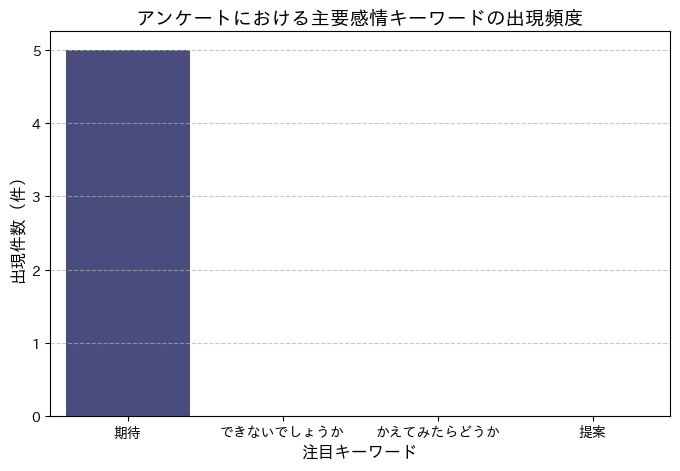

In [ ]:
# 1.感情キーワードのリスト
keywords = ["満足", "よかった", "たすかります"]
keywords = ["ほしい", "もらいたい", "いただきたい", "要望", "してください"]
keywords = ["できないでしょうか", "かえてみたらどうか", "期待", "提案"]

# 2. 集計結果を格納するための辞書
word_counts = {}

# 3. 各キーワードの出現件数をループで計算
for word in keywords:
    # str.contains でその単語が含まれる行数をカウント
    count = df["市民の声"].str.contains(word, na=False).sum()
    word_counts[word] = count

# 4. 集計結果
df_counts = pd.DataFrame(list(word_counts.items()), columns=["キーワード", "出現回数"])
df_counts = df_counts.sort_values(by="出現回数", ascending=False)

print("--- キーワード出現回数の集計結果 ---")
print(df_counts)


# 5. 【可視化】
plt.figure(figsize=(8, 5))
sns.barplot(data=df_counts, x="キーワード", y="出現回数", palette="viridis")

plt.title("アンケートにおける主要感情キーワードの出現頻度", fontsize=14)
plt.xlabel("注目キーワード", fontsize=12)
plt.ylabel("出現件数（件）", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7) # 背景に薄い補助線を引く

# グラフを表示
plt.show()

In [ ]:
"""
どんな単語が多く含まれているかを調べる
"""
from collections import Counter

all_words = []
for text in df["要望と意見"]:
    all_words.extend(extract_words(text))

# 頻出単語トップ25
word_freq = Counter(all_words).most_common(25)
print(word_freq)